# WAHIS Basic EDA

Self-contained first-pass EDA for HPAI records in `data/structured/wahis/Event-list-20_5_2026.csv`. This notebook follows the same structure as the ADIS and EMPRES-i EDA notebooks while keeping WAHIS-specific fields such as event reasons, report status, and report identifiers.


## Setup

Shared plotting, display, and helper functions used throughout the notebook.


In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

plt.style.use("ggplot")

params = {
    "text.color": (0.25, 0.25, 0.25),
    "figure.figsize": [16, 9],
}

plt.rcParams.update(params)

# Get colors from default theme.
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

import seaborn as sns
# sns.set()


from pathlib import Path

import pandas as pd


pd.options.display.max_columns = 120
pd.options.mode.chained_assignment = None
pd.options.display.max_rows = 500
pd.options.display.max_seq_items = 500

NA_VALUES = ["NaN", "nan", "", ";"]


def find_data_path(*candidates: str) -> Path:
    paths = [Path(candidate) for candidate in candidates]
    path = next((candidate for candidate in paths if candidate.exists()), None)
    if path is None:
        tried = "\n".join(str(candidate) for candidate in paths)
        raise FileNotFoundError(f"Could not find source CSV. Tried:\n{tried}")
    return path


def schema_summary(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing": data.isna().sum(),
            "missing_pct": data.isna().mean().mul(100).round(1),
            "n_unique": data.nunique(dropna=True),
        }
    ).sort_values(["missing_pct", "n_unique"], ascending=[False, False])


def top_counts(data: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    return (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(column)
        .reset_index(name="records")
    )


def plot_top_counts(
    data: pd.DataFrame, specs: list[tuple[str, int, str]], cols: int = 2
) -> None:
    rows = -(-len(specs) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 4.8 * rows), squeeze=False)
    for axis, (column, n, title) in zip(axes.ravel(), specs):
        counts = top_counts(data, column, n=n)
        sns.barplot(data=counts, y=column, x="records", ax=axis, color="#4C78A8")
        axis.set_title(title)
        axis.set_xlabel("Records")
        axis.set_ylabel("")
    for axis in axes.ravel()[len(specs) :]:
        axis.set_visible(False)
    plt.tight_layout()


def date_coverage(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "date_column": columns,
            "min_date": [data[column].min() for column in columns],
            "max_date": [data[column].max() for column in columns],
            "missing": [data[column].isna().sum() for column in columns],
            "missing_pct": [
                round(data[column].isna().mean() * 100, 1) for column in columns
            ],
        }
    )


def monthly_counts(
    data: pd.DataFrame, date_column: str, label: str = "records"
) -> pd.DataFrame:
    return (
        data.dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby("month")
        .size()
        .rename(label)
        .reset_index()
    )


def monthly_counts_by_category(
    data: pd.DataFrame,
    date_column: str,
    category_column: str,
    top_n: int = 6,
    label: str = "records",
) -> pd.DataFrame:
    top_values = top_counts(data, category_column, n=top_n)[category_column]
    return (
        data[data[category_column].isin(top_values)]
        .dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby(["month", category_column])
        .size()
        .rename(label)
        .reset_index()
    )


def country_disease_matrix(
    data: pd.DataFrame,
    country_column: str,
    disease_column: str,
    country_n: int = 12,
    disease_n: int = 8,
) -> pd.DataFrame:
    top_countries = top_counts(data, country_column, n=country_n)[country_column]
    top_diseases = top_counts(data, disease_column, n=disease_n)[disease_column]
    filtered = data[
        data[country_column].isin(top_countries)
        & data[disease_column].isin(top_diseases)
    ]
    return pd.crosstab(filtered[country_column], filtered[disease_column])


import contextily as cx
import geopandas as gpd

BASEMAP_SOURCE = cx.providers.CartoDB.Positron


def plot_event_map(
    data: pd.DataFrame,
    longitude_column: str,
    latitude_column: str,
    color_column: str,
    title: str,
    sample_n: int | None = None,
    marker_size: float = 18,
    alpha: float = 0.65,
) -> gpd.GeoDataFrame:
    geo_data = data.dropna(subset=[longitude_column, latitude_column]).copy()
    if sample_n is not None and len(geo_data) > sample_n:
        geo_data = geo_data.sample(sample_n, random_state=42)

    gdf = gpd.GeoDataFrame(
        geo_data,
        geometry=gpd.points_from_xy(
            geo_data[longitude_column], geo_data[latitude_column]
        ),
        crs="EPSG:4326",
    ).to_crs(epsg=3857)

    fig, axis = plt.subplots(figsize=(11, 9))
    gdf.plot(
        ax=axis,
        column=color_column,
        categorical=True,
        legend=True,
        markersize=marker_size,
        alpha=alpha,
        linewidth=0,
    )
    cx.add_basemap(axis, source=BASEMAP_SOURCE, attribution_size=7)
    axis.set_title(title)
    axis.set_axis_off()
    plt.tight_layout()
    return gdf


## Load Data

WAHIS uses semicolon-delimited CSV exports and `dd.mm.yyyy`-style dates.


In [ ]:
DATA_PATH = find_data_path(
    "../data/structured/wahis/Event-list-20_5_2026.csv",
    "data/structured/wahis/Event-list-20_5_2026.csv",
)

raw_df = pd.read_csv(DATA_PATH, sep=";", na_values=NA_VALUES, keep_default_na=True)

print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]:,} columns from {DATA_PATH}")
raw_df.head()

Loaded 2,100 rows and 10 columns from ../data/structured/wahis/Event-list-20_5_2026.csv


,country,eventId,reportId,disease,subType,eventStartDate,reason,reportStatus,submissionDate,reportNumber
0,Spain,7151-ytb08,183170-83w14,Newcastle disease virus (Inf. with),NaN,23.12.2025,Recurrence of an eradicated disease,Validated,14.5.2026,FUR_9
1,Poland,7451-fc6d1,183114-t10zj,High pathogenicity avian influenza viruses (In...,H5N1,14.4.2026,Recurrence of an eradicated disease,Validated,14.5.2026,FUR_6
2,Hungary,7185-aczd0,183167-5b6um,High pathogenicity avian influenza viruses (In...,H5N1,9.1.2026,Recurrence of an eradicated disease,Validated,14.5.2026,FUR_2
3,Hungary,7237-1imgk,183166-7pu5m,High pathogenicity avian influenza viruses (In...,H5N1,27.1.2026,Recurrence of an eradicated disease,Validated,14.5.2026,FUR_2
4,Hungary,7228-z89wj,183165-4ue80,High pathogenicity avian influenza viruses (In...,H5N1,24.1.2026,Recurrence of an eradicated disease,Validated,14.5.2026,FUR_3


## Clean Working Copy

Parse dates, filter to HPAI records, add a submission delay, and keep the original source column names so they remain traceable to the export.


In [ ]:
df = raw_df.copy()
df.columns = df.columns.str.strip()

HPAI_MATCH_COLUMNS = ["disease", "subType"]
hpai_mask = pd.Series(False, index=df.index)
for column in HPAI_MATCH_COLUMNS:
    hpai_mask |= (
        df[column]
        .fillna("")
        .str.contains(
            "HPAI|high pathogenic|high pathogenicity avian influenza",
            case=False,
            regex=True,
        )
    )

df = df.loc[hpai_mask].copy()
print(f"Filtered to {len(df):,} HPAI records from {len(raw_df):,} total WAHIS records.")

DATE_COLUMNS = ["eventStartDate", "submissionDate"]
for column in DATE_COLUMNS:
    df[column] = pd.to_datetime(df[column], dayfirst=True, errors="coerce")

df["submission_delay_days"] = (df["submissionDate"] - df["eventStartDate"]).dt.days

id_columns = ["eventId", "reportId", "reportNumber"]
duplicate_summary = pd.Series(
    {
        f"duplicate_{column}": df[column].duplicated().sum()
        for column in id_columns
        if column in df.columns
    }
)

display(df.dtypes.to_frame("dtype"))
display(duplicate_summary.to_frame("count"))

Filtered to 946 HPAI records from 2,100 total WAHIS records.


,dtype
country,str
eventId,str
reportId,str
disease,str
subType,str
eventStartDate,datetime64[us]
reason,str
reportStatus,str
submissionDate,datetime64[us]
reportNumber,str


,count
duplicate_eventId,0
duplicate_reportId,0
duplicate_reportNumber,881


## Dataset Overview And Completeness


In [4]:
overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "countries": [df["country"].nunique()],
        "diseases": [df["disease"].nunique()],
        "subtypes": [df["subType"].nunique()],
        "event_reasons": [df["reason"].nunique()],
        "first_event_start": [df["eventStartDate"].min()],
        "last_event_start": [df["eventStartDate"].max()],
    }
)

display(overview)
display(schema_summary(df))
display(date_coverage(df, DATE_COLUMNS))

,rows,columns,countries,diseases,subtypes,event_reasons,first_event_start,last_event_start
0,946,11,39,2,12,7,2017-05-30,2026-04-25


,dtype,missing,missing_pct,n_unique
eventId,str,0,0.0,946
reportId,str,0,0.0,946
eventStartDate,datetime64[us],0,0.0,684
submissionDate,datetime64[us],0,0.0,478
submission_delay_days,int64,0,0.0,376
reportNumber,str,0,0.0,65
country,str,0,0.0,39
subType,str,0,0.0,12
reason,str,0,0.0,7
disease,str,0,0.0,2


,date_column,min_date,max_date,missing,missing_pct
0,eventStartDate,2017-05-30,2026-04-25,0,0.0
1,submissionDate,2020-02-21,2026-05-20,0,0.0


## Top Categories


In [5]:
CATEGORY_COLUMNS = ["country", "disease", "subType", "reason", "reportStatus"]

for column in CATEGORY_COLUMNS:
    display(top_counts(df, column, n=20))

,country,records
0,Germany,166
1,Russia,66
2,United Kingdom,65
3,Poland,62
4,Hungary,62
5,Sweden,41
6,Moldova,38
7,Denmark,31
8,Ukraine,29
9,Portugal,29


,disease,records
0,Influenza A viruses of high pathogenicity (Inf...,522
1,High pathogenicity avian influenza viruses (In...,424


,subType,records
0,H5N1,682
1,H5N8,120
2,H5 (N untyped),57
3,H5N5,51
4,Untyped or partially typed,10
5,H5N3,8
6,H5N4,8
7,H5N2,5
8,Pending,2
9,H7N7,1


,reason,records
0,Recurrence of an eradicated disease,706
1,First occurrence in a zone or a compartment,77
2,Recurrence of an eradicated strain,75
3,New strain in the country,39
4,Unusual host species,20
5,New strain in a zone or a compartment,17
6,First occurrence in the country,12


,reportStatus,records
0,Validated,946


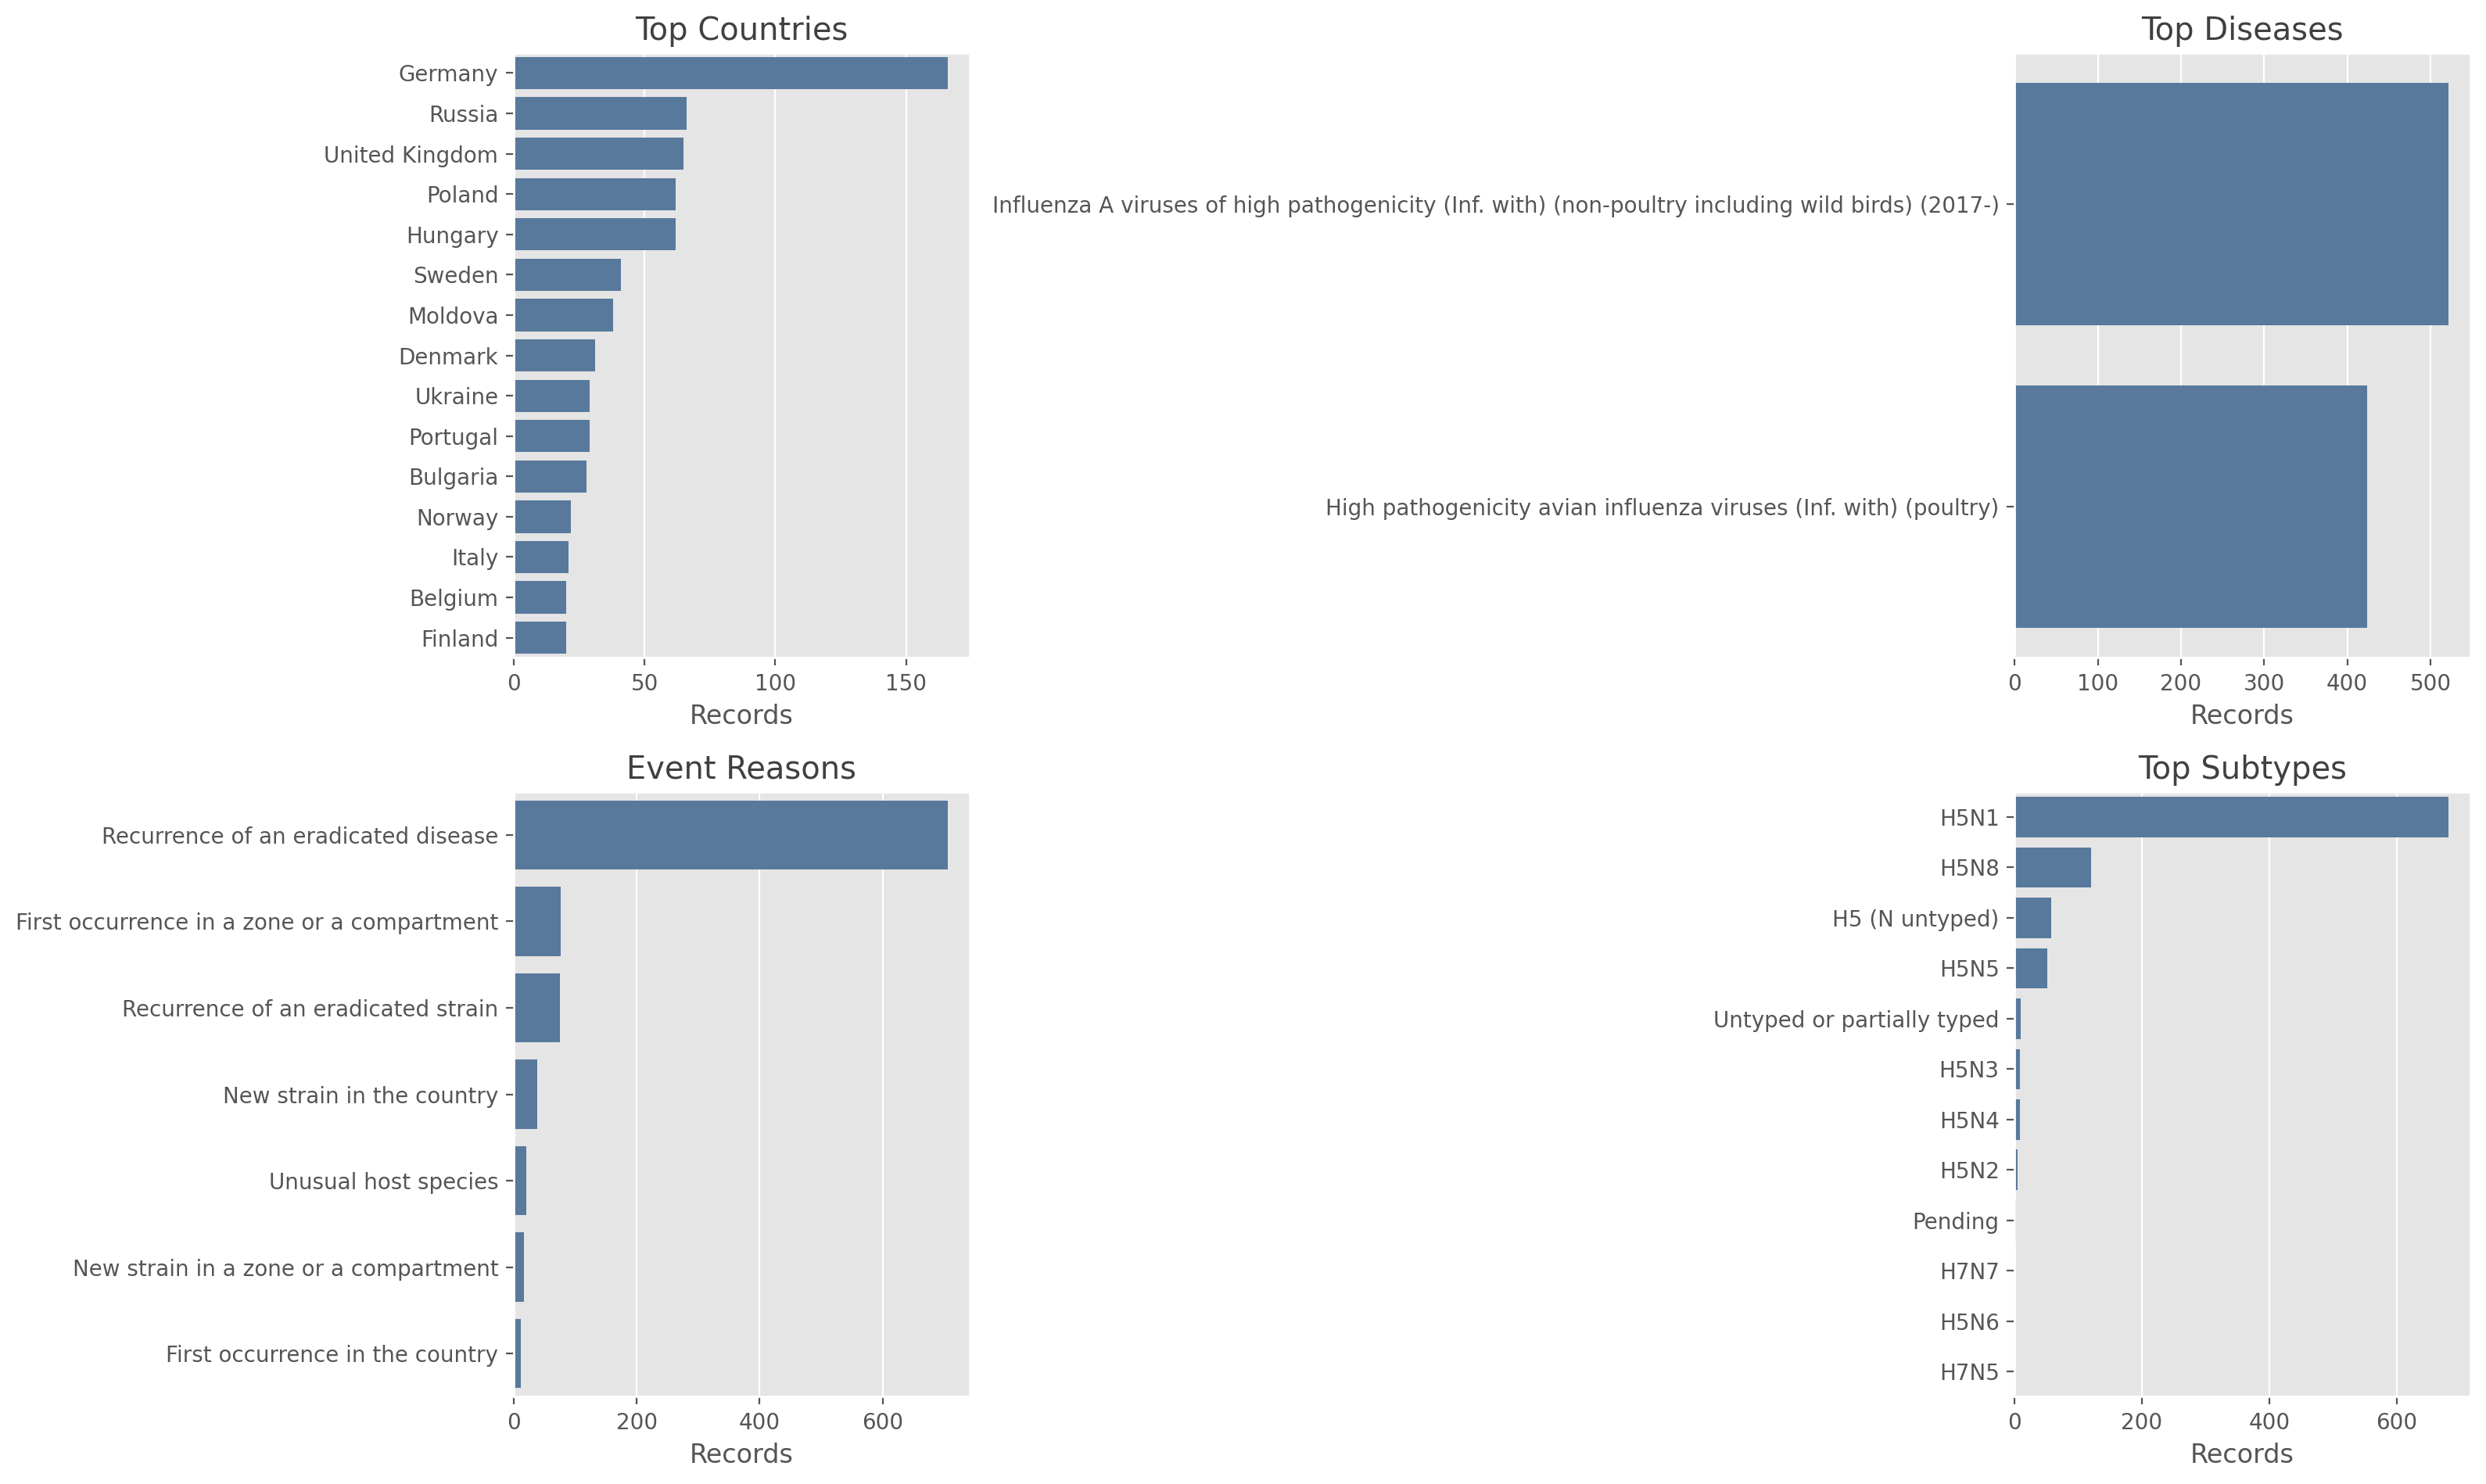

In [ ]:
plot_top_counts(
    df,
    [
        ("country", 15, "Top Countries"),
        ("disease", 12, "Top Diseases"),
        ("reason", 12, "Event Reasons"),
        ("subType", 12, "Top Subtypes"),
    ],
)


## Time Coverage And Trends


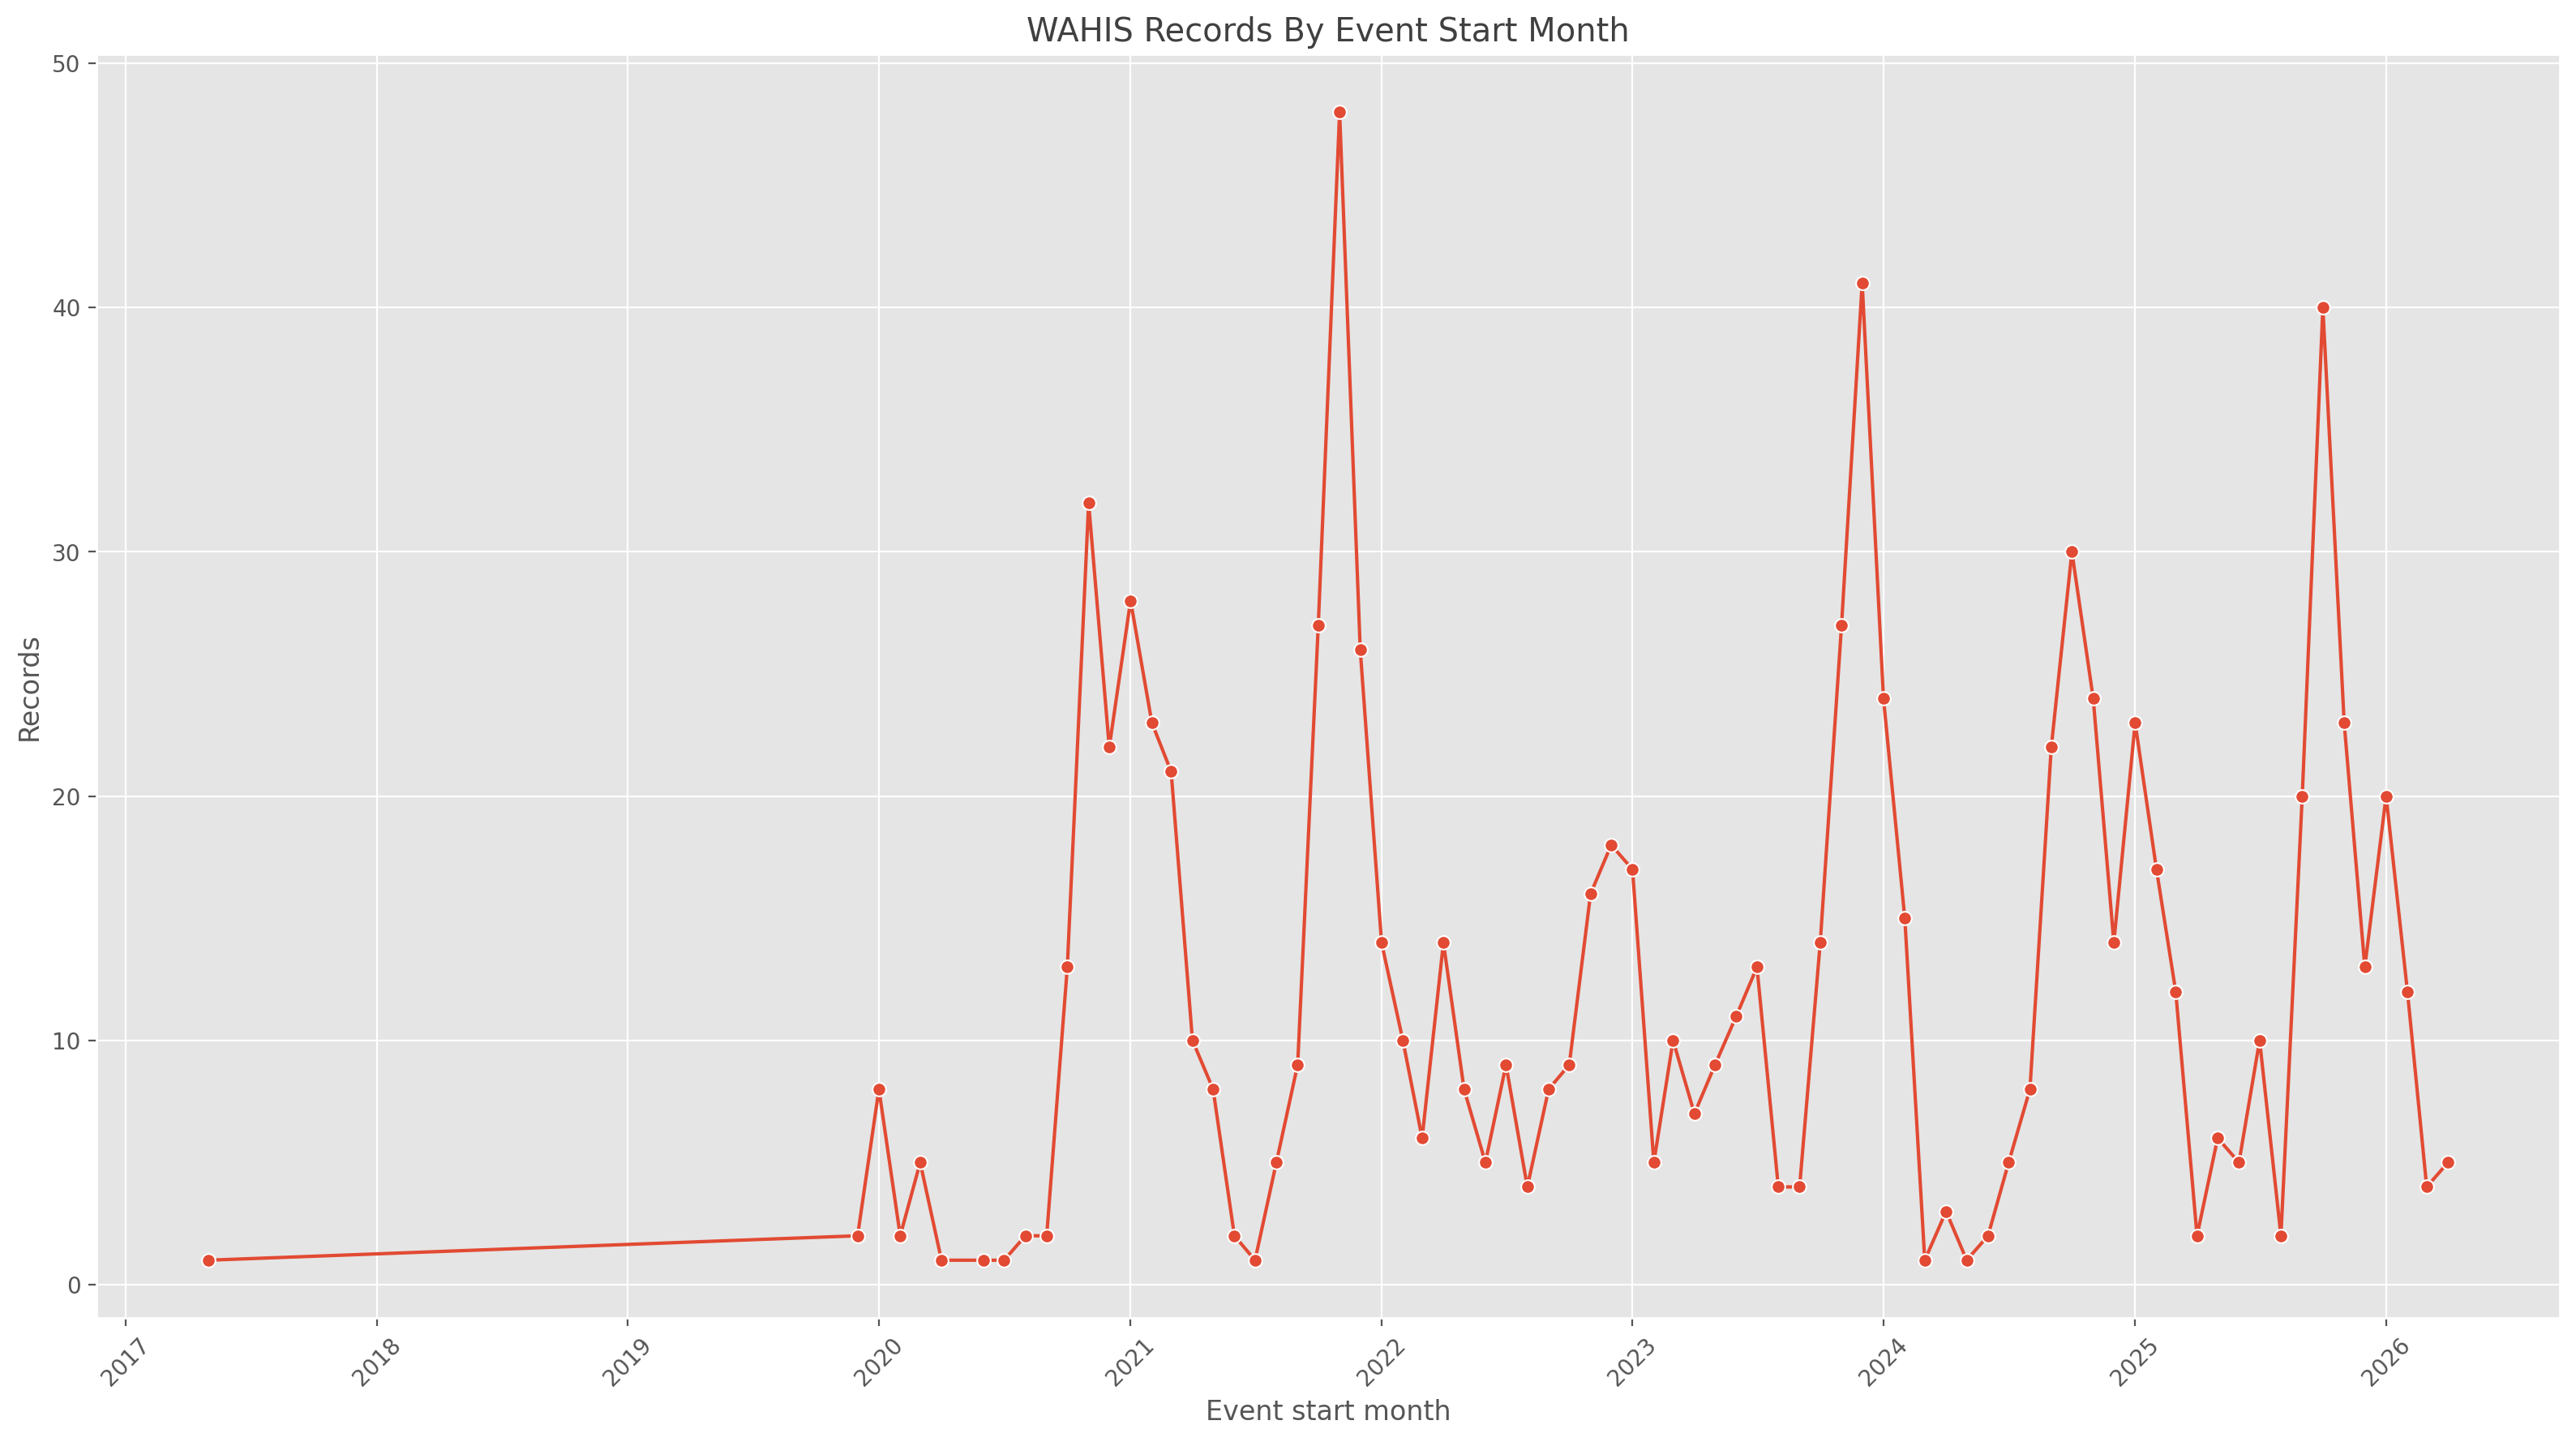

In [ ]:
events_by_month = monthly_counts(df, "eventStartDate")

sns.lineplot(data=events_by_month, x="month", y="records", marker="o")
plt.title("WAHIS Records By Event Start Month")
plt.xlabel("Event start month")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.tight_layout()

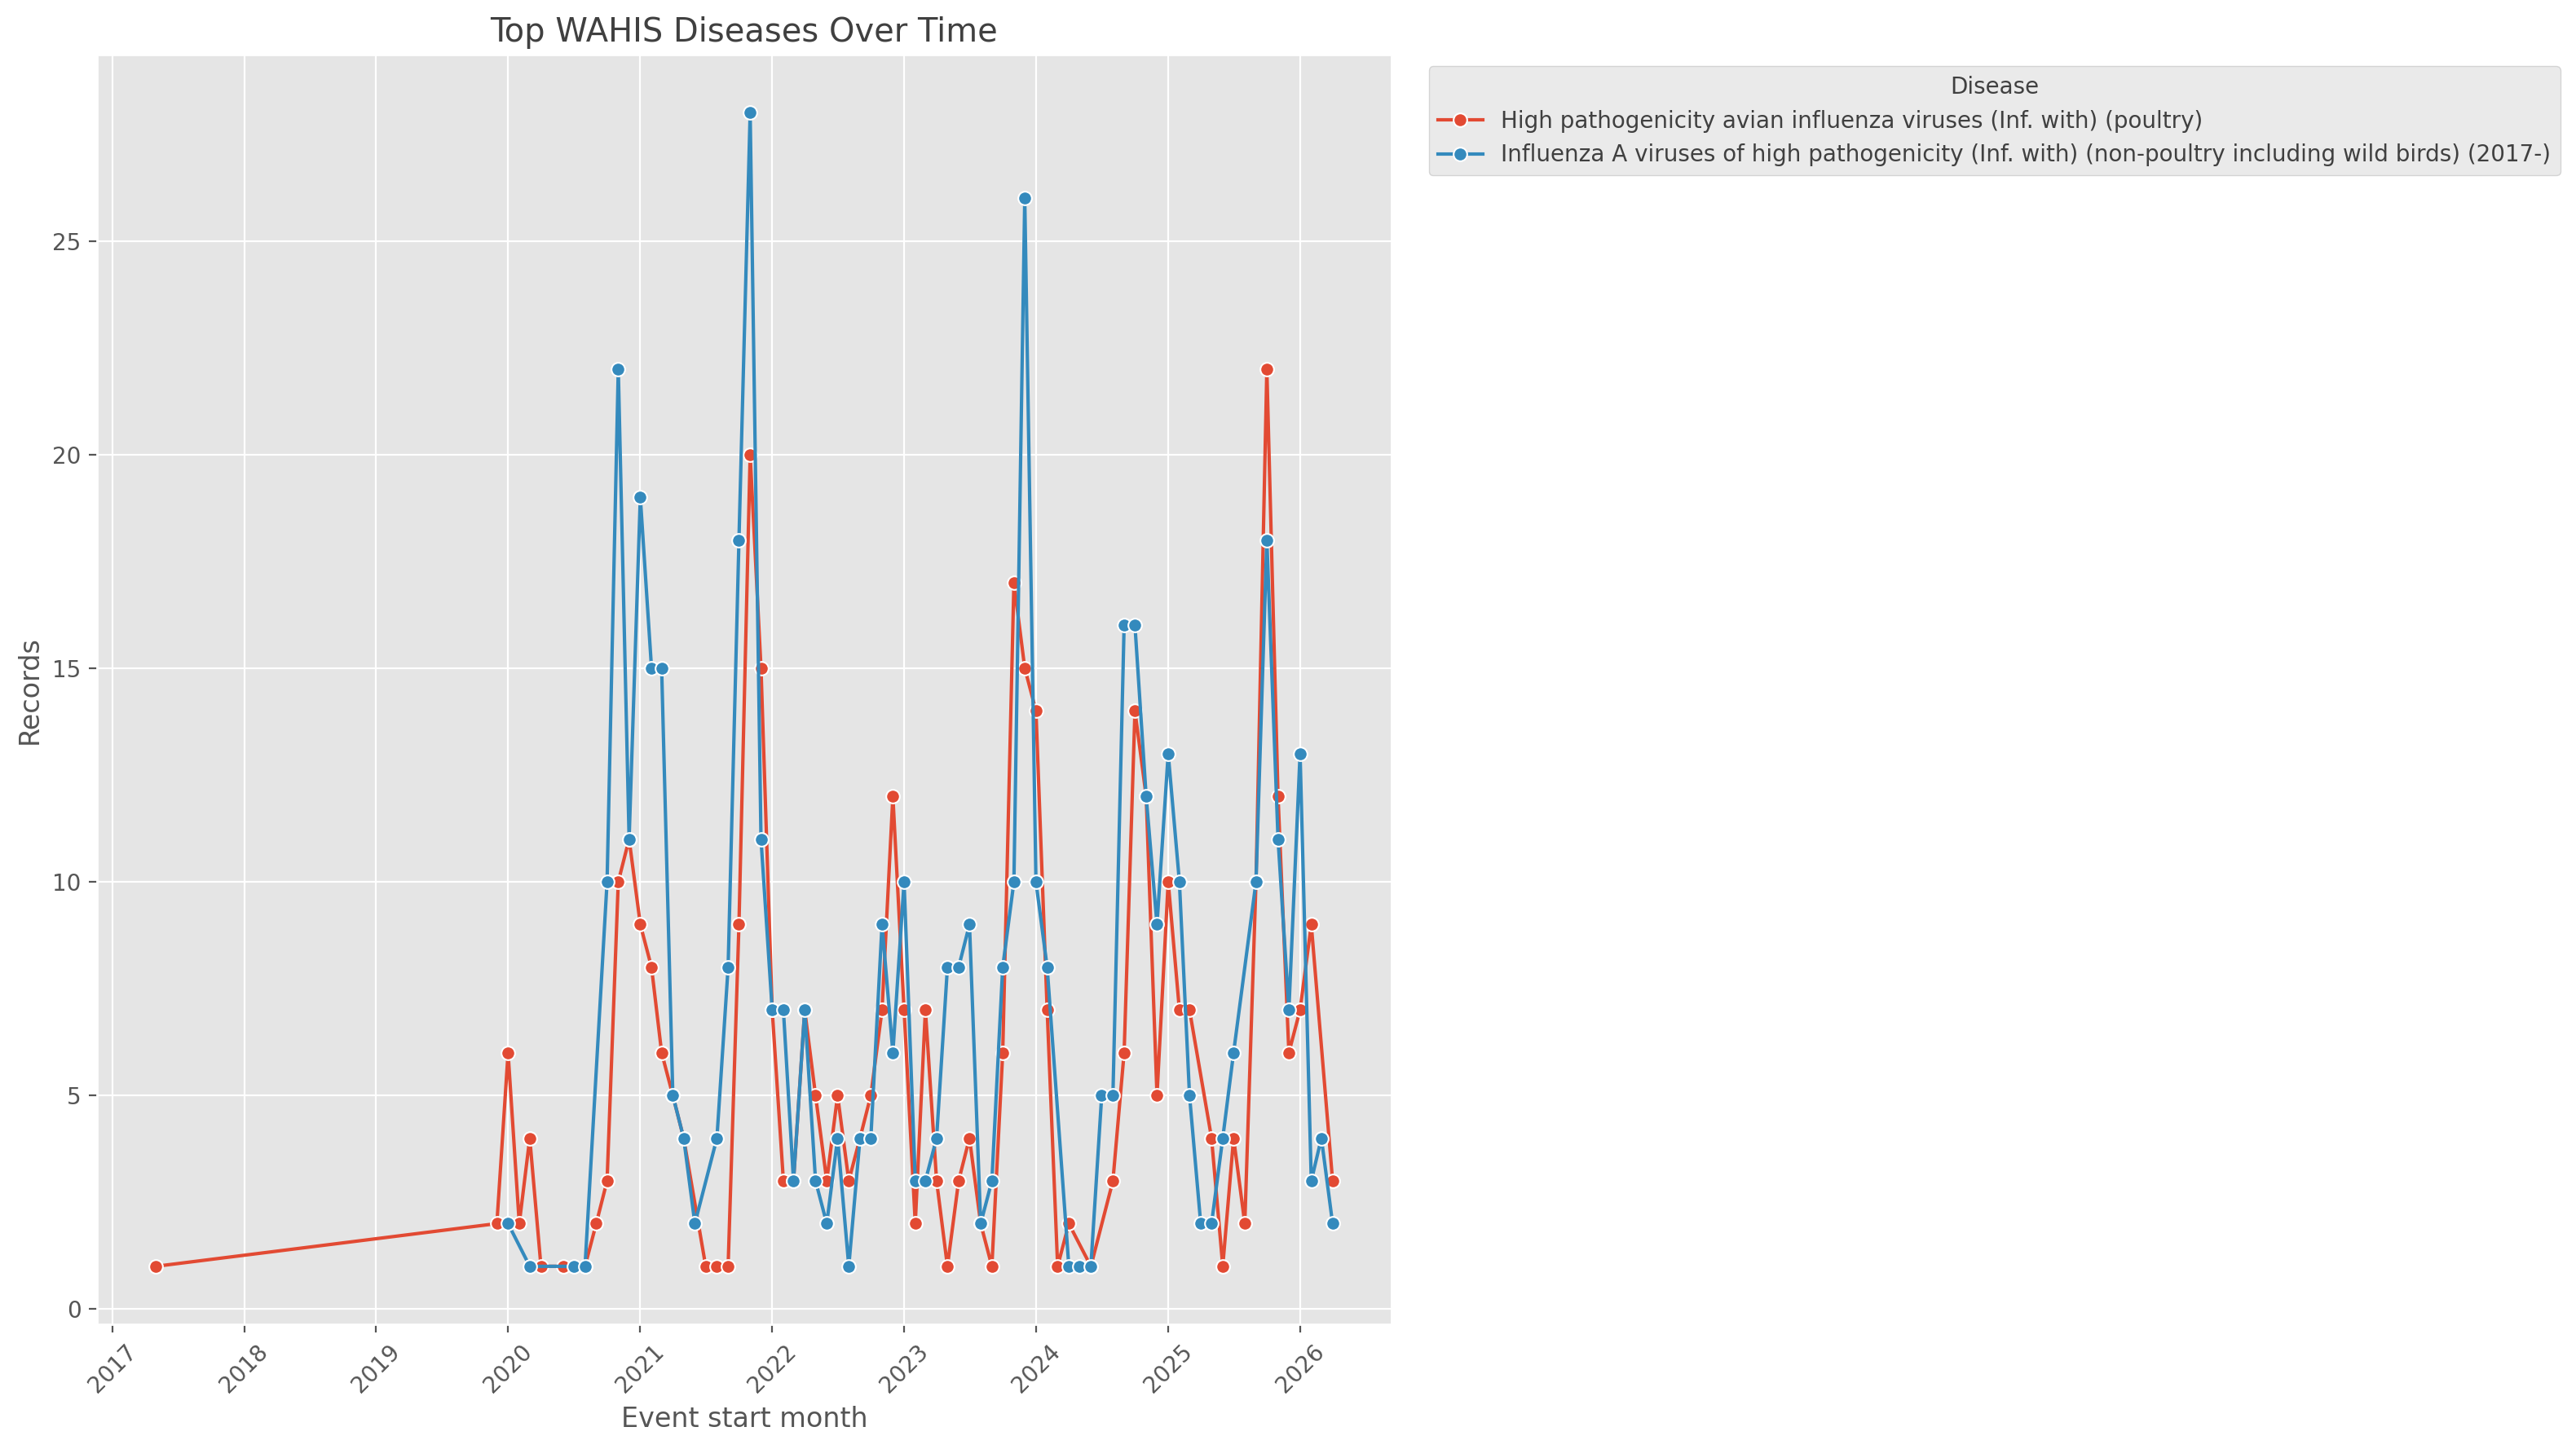

In [ ]:
events_by_month_and_disease = monthly_counts_by_category(
    df,
    date_column="eventStartDate",
    category_column="disease",
    top_n=6,
)

sns.lineplot(
    data=events_by_month_and_disease,
    x="month",
    y="records",
    hue="disease",
    marker="o",
)
plt.title("Top WAHIS Diseases Over Time")
plt.xlabel("Event start month")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.legend(title="Disease", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Delay Analysis


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
submission_delay_days,946.0,173.325581,174.649829,0.0,37.0,67.0,126.0,210.0,348.0,520.5,1353.0


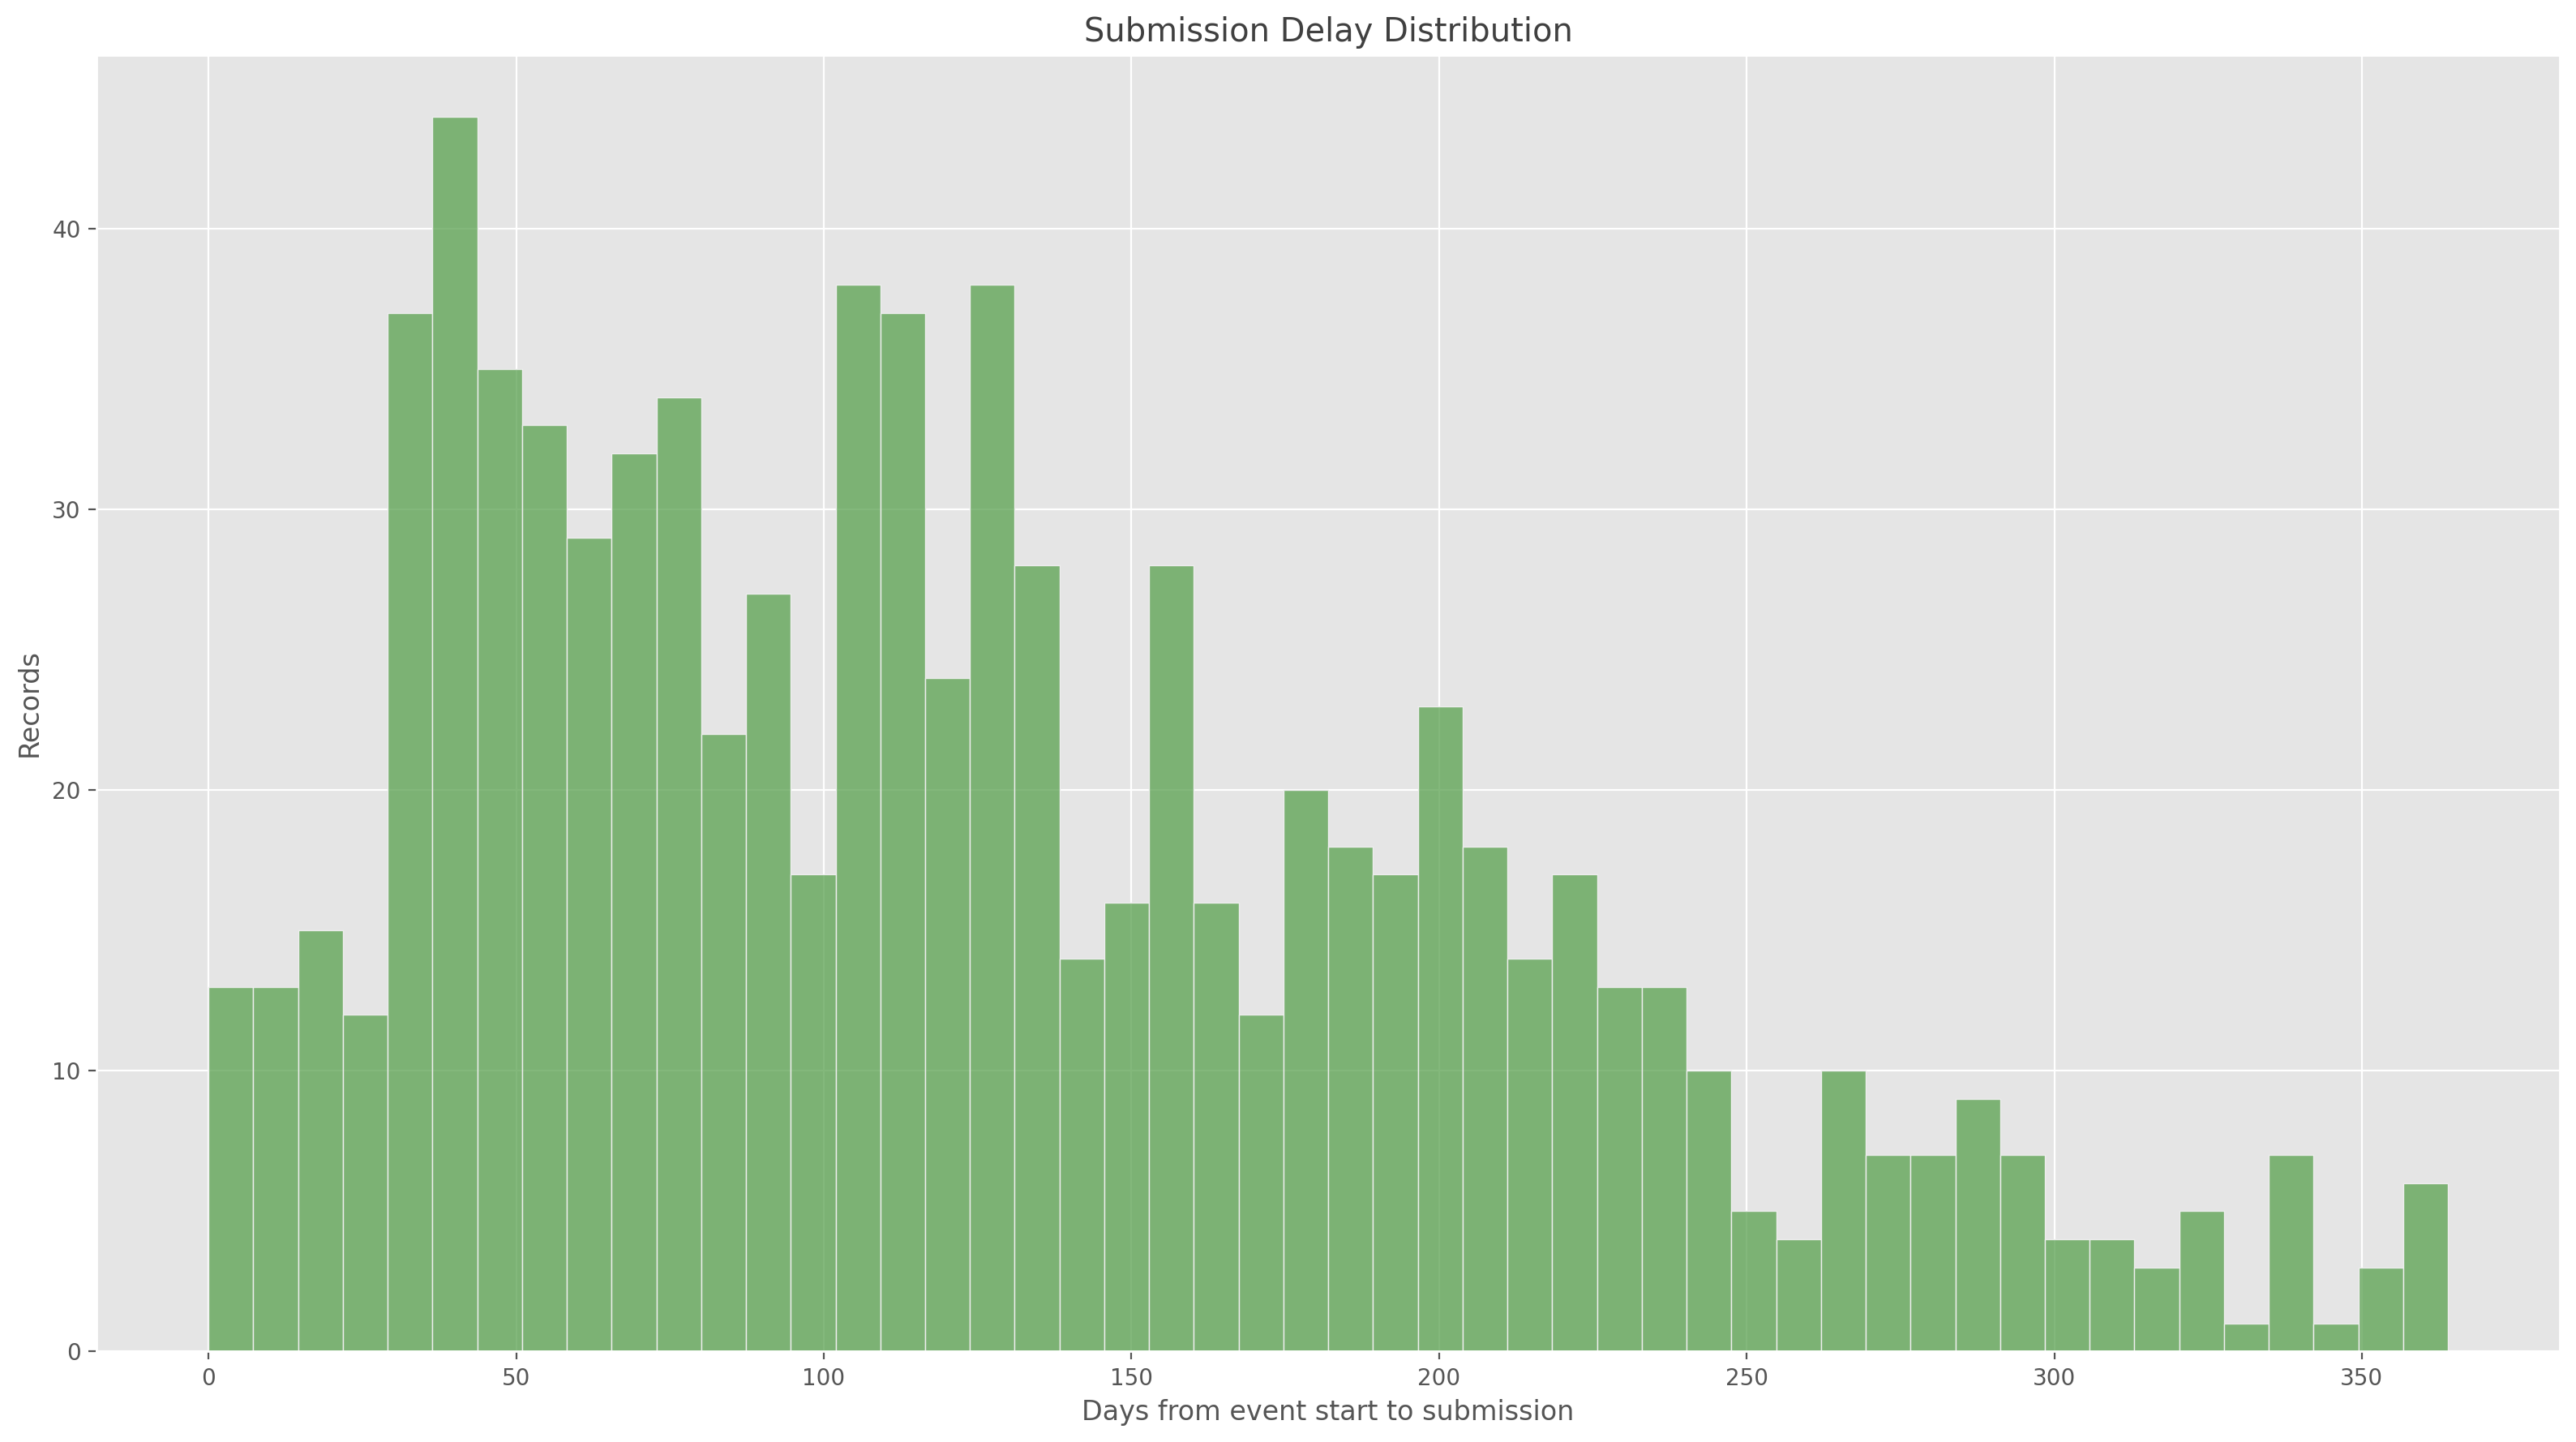

In [9]:
delay_columns = ["submission_delay_days"]

display(df[delay_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T)

valid_delays = df.loc[
    df["submission_delay_days"].between(-30, 365), "submission_delay_days"
]
sns.histplot(valid_delays, bins=50, color="#59A14F")
plt.title("Submission Delay Distribution")
plt.xlabel("Days from event start to submission")
plt.ylabel("Records")
plt.tight_layout()

In [10]:
df.loc[
    df["submission_delay_days"].notna(),
    [
        "country",
        "disease",
        "subType",
        "eventStartDate",
        "submissionDate",
        "submission_delay_days",
        "reason",
    ],
].sort_values("submission_delay_days", ascending=False).head(20)

,country,disease,subType,eventStartDate,submissionDate,submission_delay_days,reason
1064,Luxembourg,High pathogenicity avian influenza viruses (In...,H5N8,2017-05-30,2021-02-11,1353,Recurrence of an eradicated disease
1476,Hungary,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-11-04,2025-07-09,1343,Recurrence of an eradicated disease
1546,Poland,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-11-08,2025-05-20,1289,Recurrence of an eradicated disease
1548,France,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-11-08,2025-05-19,1288,Recurrence of an eradicated disease
1636,Belgium,Influenza A viruses of high pathogenicity (Inf...,H5 (N untyped),2021-11-15,2025-03-12,1213,Recurrence of an eradicated disease
1739,Belgium,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-11-05,2024-12-10,1131,Recurrence of an eradicated disease
1638,Belgium,Influenza A viruses of high pathogenicity (Inf...,H5 (N untyped),2022-04-07,2025-03-12,1070,Unusual host species
1912,Germany,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-10-13,2024-05-08,938,Recurrence of an eradicated disease
1911,Germany,Influenza A viruses of high pathogenicity (Inf...,H5N1,2021-10-14,2024-05-08,937,Recurrence of an eradicated disease
1876,Norway,Influenza A viruses of high pathogenicity (Inf...,H5N1,2022-01-04,2024-07-09,917,Recurrence of an eradicated disease


## Country-Disease Matrix


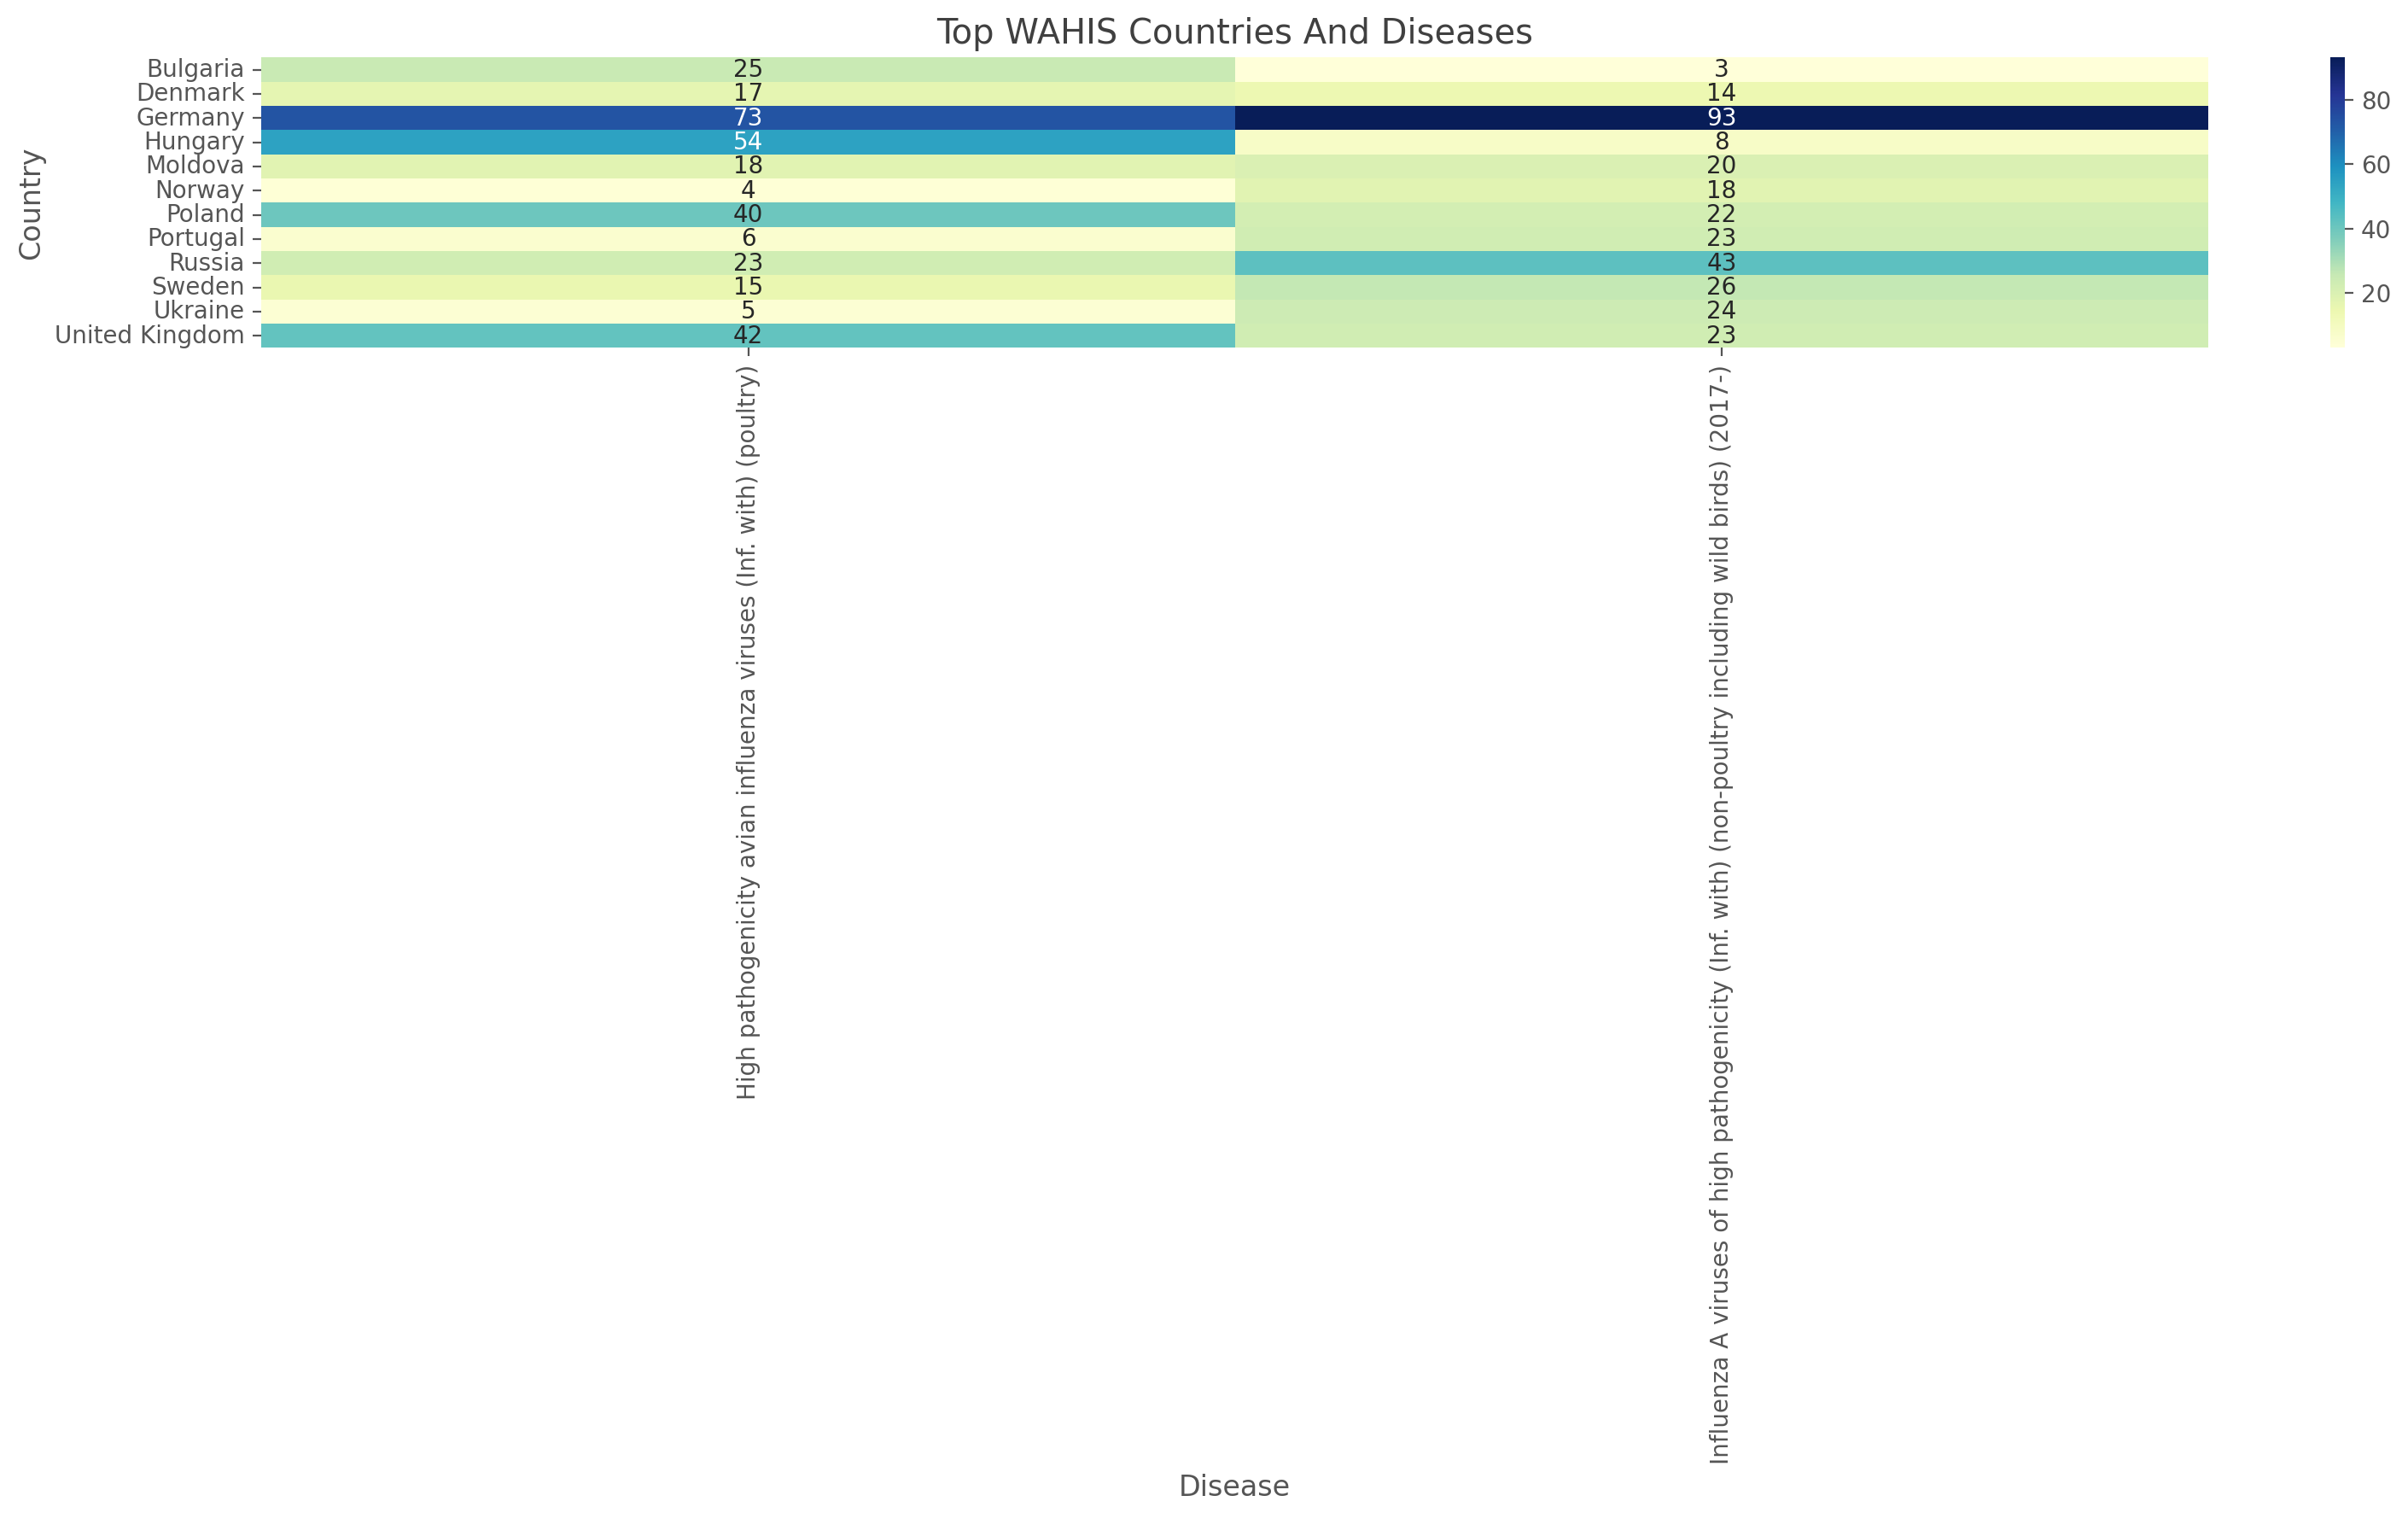

In [ ]:
matrix = country_disease_matrix(df, "country", "disease")

sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Top WAHIS Countries And Diseases")
plt.xlabel("Disease")
plt.ylabel("Country")
plt.tight_layout()

## Geographic Snapshot

This WAHIS export does not include latitude/longitude or administrative geometry fields, so there are no event-level points to map. Use the country-disease matrix above for geographic screening in this source, or join countries to a boundary layer in a separate enrichment step.


In [12]:
missing_geo_fields = sorted({"Latitude", "Longitude"} - set(df.columns))
pd.Series(
    {
        "has_event_coordinates": not missing_geo_fields,
        "missing_geo_fields": ", ".join(missing_geo_fields),
        "available_country_field": "country" in df.columns,
    }
)

has_event_coordinates                    False
missing_geo_fields         Latitude, Longitude
available_country_field                   True
dtype: object

## Source-Specific Signals

WAHIS has no coordinates in this export, so the source-specific checks focus on event reasons, report status, identifiers, and latest submissions.


In [13]:
source_specific = {
    "reason_by_disease": pd.crosstab(df["disease"], df["reason"], dropna=False),
    "status_by_reason": pd.crosstab(df["reason"], df["reportStatus"], dropna=False),
    "reports_per_event": df.groupby("eventId")["reportId"]
    .nunique()
    .sort_values(ascending=False),
}

display(source_specific["reason_by_disease"].head(20))
display(source_specific["status_by_reason"])
display(source_specific["reports_per_event"].head(20).to_frame("reports"))

reason,First occurrence in a zone or a compartment,First occurrence in the country,New strain in a zone or a compartment,New strain in the country,Recurrence of an eradicated disease,Recurrence of an eradicated strain,Unusual host species
disease,,,,,,,
High pathogenicity avian influenza viruses (Inf. with) (poultry),31,6,4,5,356,22,0
Influenza A viruses of high pathogenicity (Inf. with) (non-poultry including wild birds) (2017-),46,6,13,34,350,53,20


reportStatus,Validated
reason,
First occurrence in a zone or a compartment,77
First occurrence in the country,12
New strain in a zone or a compartment,17
New strain in the country,39
Recurrence of an eradicated disease,706
Recurrence of an eradicated strain,75
Unusual host species,20


,reports
eventId,
2290-uagju,1
5810-lt1en,1
5646-6jkwk,1
5689-9mgk5,1
5700-m8fdw,1
5723-wwezx,1
5737-90rci,1
5745-5fiml,1
5789-go8l2,1


In [14]:
df.sort_values("submissionDate", ascending=False)[
    [
        "country",
        "disease",
        "subType",
        "eventStartDate",
        "submissionDate",
        "reason",
        "reportStatus",
        "eventId",
        "reportId",
    ]
].head(25)

,country,disease,subType,eventStartDate,submissionDate,reason,reportStatus,eventId,reportId
2000,Latvia,Influenza A viruses of high pathogenicity (Inf...,H5N2,2025-11-09,2026-05-20,New strain in the country,Validated,7187-kfluc,183317-0s3uh
2001,Latvia,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-09-20,2026-05-20,Recurrence of an eradicated strain,Validated,6825-otnf3,183316-b9sm7
2007,Denmark,High pathogenicity avian influenza viruses (In...,H5N1,2025-10-06,2026-05-19,Recurrence of an eradicated disease,Validated,6858-he14p,183010-j1sb6
2008,Norway,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-03-03,2026-05-19,Recurrence of an eradicated strain,Validated,6308-yc8ki,183304-2ka2w
2010,Lithuania,High pathogenicity avian influenza viruses (In...,H5N1,2025-10-12,2026-05-19,Recurrence of an eradicated disease,Validated,6885-46x0g,183127-0tjvv
2011,Poland,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-11-23,2026-05-19,Recurrence of an eradicated disease,Validated,7066-my686,183297-q8x26
2021,Poland,High pathogenicity avian influenza viruses (In...,H5N1,2025-12-17,2026-05-18,Recurrence of an eradicated disease,Validated,7137-312gc,183278-p0iz9
2028,Poland,Influenza A viruses of high pathogenicity (Inf...,H5N1,2026-01-16,2026-05-18,Recurrence of an eradicated disease,Validated,7215-q301v,183270-8rg5y
2027,Poland,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-12-15,2026-05-18,Recurrence of an eradicated strain,Validated,7127-cl8en,183271-ni5ww
2026,Poland,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-12-01,2026-05-18,Recurrence of an eradicated disease,Validated,7096-4m5b3,183272-btt2e


## Quick Filters

Set any filter to a string value, or leave it as `None` to ignore that filter.


In [15]:
country_filter = None
disease_filter = None
reason_filter = None
subtype_filter = None

filtered = df.copy()
if country_filter:
    filtered = filtered[filtered["country"].eq(country_filter)]
if disease_filter:
    filtered = filtered[filtered["disease"].eq(disease_filter)]
if reason_filter:
    filtered = filtered[filtered["reason"].eq(reason_filter)]
if subtype_filter:
    filtered = filtered[filtered["subType"].eq(subtype_filter)]

filtered.sort_values("submissionDate", ascending=False).head(50)

,country,eventId,reportId,disease,subType,eventStartDate,reason,reportStatus,submissionDate,reportNumber,submission_delay_days
2000,Latvia,7187-kfluc,183317-0s3uh,Influenza A viruses of high pathogenicity (Inf...,H5N2,2025-11-09,New strain in the country,Validated,2026-05-20,FUR_14,192
2001,Latvia,6825-otnf3,183316-b9sm7,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-09-20,Recurrence of an eradicated strain,Validated,2026-05-20,FUR_28,242
2007,Denmark,6858-he14p,183010-j1sb6,High pathogenicity avian influenza viruses (In...,H5N1,2025-10-06,Recurrence of an eradicated disease,Validated,2026-05-19,FUR_36,225
2008,Norway,6308-yc8ki,183304-2ka2w,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-03-03,Recurrence of an eradicated strain,Validated,2026-05-19,FUR_94,442
2010,Lithuania,6885-46x0g,183127-0tjvv,High pathogenicity avian influenza viruses (In...,H5N1,2025-10-12,Recurrence of an eradicated disease,Validated,2026-05-19,FUR_6,219
2011,Poland,7066-my686,183297-q8x26,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-11-23,Recurrence of an eradicated disease,Validated,2026-05-19,FUR_23,177
2021,Poland,7137-312gc,183278-p0iz9,High pathogenicity avian influenza viruses (In...,H5N1,2025-12-17,Recurrence of an eradicated disease,Validated,2026-05-18,FUR_20,152
2028,Poland,7215-q301v,183270-8rg5y,Influenza A viruses of high pathogenicity (Inf...,H5N1,2026-01-16,Recurrence of an eradicated disease,Validated,2026-05-18,FUR_13,122
2027,Poland,7127-cl8en,183271-ni5ww,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-12-15,Recurrence of an eradicated strain,Validated,2026-05-18,FUR_21,154
2026,Poland,7096-4m5b3,183272-btt2e,Influenza A viruses of high pathogenicity (Inf...,H5N1,2025-12-01,Recurrence of an eradicated disease,Validated,2026-05-18,FUR_18,168
